# B1, b2, b3 Comparison: 200 GeV Extended vs 26 GeV Extended

## Objective

Compare the main field **B1** (T), normal quadrupole **b2** (units), and normal
sextupole **b3** (units) at two operating points:

- **Injection before MD1** (~301 A, 26 GeV) -- the MD1 injection plateau
- **Top of SFTPRO** (~4815 A, 400 GeV) -- the SFTPRO flat-top

for two measurement campaigns on the same SPS MBB dipole:

| Dataset | Path | Description |
|---------|------|-------------|
| **200 GeV extended** | `01_200_extended` | Extended measurement, 200 GeV cycle |
| **26 GeV extended** | `03_26_extended` | Extended measurement, 26 GeV cycle |

Both share the supercycle **LHC_pilot -> MD1 -> SFTPRO** (~20 repetitions)
but were measured in separate sessions (~30 min apart).

### Settling Correction

At injection (~301 A), each supercycle has ~24 turns. The first few are
contaminated by eddy-current settling. This notebook keeps only the
**last N_LAST_TURNS_INJ** turns per supercycle and removes outliers via
MAD-based sigma clipping on B1.

---
## 1. Configuration

In [1]:
SESSION_200 = "2026_02_06/01_200_extended/20260206_144537_SPS_MBB"
SUBDIR_200  = "20260206_144559_MBB"
SESSION_26 = "2026_02_06/03_26_extended/20260206_151808_SPS_MBB"
SUBDIR_26  = "20260206_151827_MBB"

SEGMENT = "NCS"
KN_CROSS_SESSION = "20251212_171026_SPS_MBA/CRMMMMH_AV-00000001/Kn_values_Seg_Main_A_AC.txt"
MAGNET_ORDER = 1
R_REF = 0.02
SAMPLES_PER_TURN = 1024
OPTIONS = ("dri", "rot", "cel", "fed")
PLATEAU_I_RANGE_MAX = 2.5
MIN_B1_T = 1e-4
N_LAST_TURNS_INJ = 18
N_LAST_TURNS_HIGH = None
N_SIGMA_CLIP = 5
MIN_SC_TURNS = 15         # minimum turns per supercycle (skip partial fragments)
N_SKIP_END_SC = 1         # trim last N turns per injection group (ramp contamination)
FLIP_FIELD_SIGN = False

print("B1 / b2 / b3 Comparison: 200 GeV vs 26 GeV Extended")
print("=" * 55)
print(f"  200 GeV : {SESSION_200}")
print(f"  26 GeV  : {SESSION_26}")
print(f"  Segment : {SEGMENT}")
print(f"  N_LAST_TURNS_INJ  = {N_LAST_TURNS_INJ}")
print(f"  N_SIGMA_CLIP      = {N_SIGMA_CLIP}")

B1 / b2 / b3 Comparison: 200 GeV vs 26 GeV Extended
  200 GeV : 2026_02_06/01_200_extended/20260206_144537_SPS_MBB
  26 GeV  : 2026_02_06/03_26_extended/20260206_151808_SPS_MBB
  Segment : NCS
  N_LAST_TURNS_INJ  = 18
  N_SIGMA_CLIP      = 5


---
## 2. Imports

In [2]:
import sys
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

%matplotlib widget
plt.rcParams.update({"figure.figsize": (14, 5), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 100})

REPO_ROOT = Path(".").resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "pyproject.toml").exists() or (REPO_ROOT / ".git").exists(): break
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    compute_block_averaged_range, detect_plateau_turns, classify_current,
    find_contiguous_groups, process_kn_pipeline, build_harmonic_rows,
    mad_sigma_clip, diagnose_cel_fed,
    FdiTransitionCheck, diagnose_fdi_transitions,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

KN_PATH = REPO_ROOT / "measurements" / KN_CROSS_SESSION
assert KN_PATH.exists(), f"Kn file not found: {KN_PATH}"
kn = load_segment_kn_txt(str(KN_PATH))
print(f"Kn loaded: {len(kn.orders)} harmonics from {KN_PATH.name}")
print("Imports ready.")

Kn loaded: 15 harmonics from Kn_values_Seg_Main_A_AC.txt
Imports ready.


---
## 3. cel/fed Safety Diagnostic

In [3]:
Ns = SAMPLES_PER_TURN
m = MAGNET_ORDER
FILE_PAT = re.compile(r"Run_(\d+)_I_([\d.]+)A_(N?CS)_raw_measurement_data\.txt$")

_session_dir = REPO_ROOT / "measurements" / SESSION_200
_run_dir = _session_dir / SUBDIR_200
_ncs_files = [f for f in sorted(_run_dir.iterdir()) if FILE_PAT.search(f.name) and SEGMENT in f.name]
assert _ncs_files, "No NCS raw file found"
_raw = np.loadtxt(_ncs_files[0])
_n_turns = _raw.shape[0] // Ns; _n_keep = _n_turns * Ns

_t_all = _raw[:_n_keep, 0].reshape(_n_turns, Ns)
_flux_abs = _raw[:_n_keep, 1].reshape(_n_turns, Ns)
_flux_cmp = _raw[:_n_keep, 2].reshape(_n_turns, Ns)
_I_all = _raw[:_n_keep, 3].reshape(_n_turns, Ns)

_I_mean_quick = _I_all.mean(axis=1)
_best_turn = np.argmax(np.abs(_I_mean_quick))
_r1 = robust_range(_raw[_best_turn*Ns:(_best_turn+1)*Ns, 1])
_r2 = robust_range(_raw[_best_turn*Ns:(_best_turn+1)*Ns, 2])
if _r2 > _r1:
    _flux_abs = _raw[:_n_keep, 2].reshape(_n_turns, Ns)
    _flux_cmp = _raw[:_n_keep, 1].reshape(_n_turns, Ns)

_I_mean = _I_all.mean(axis=1)
_hi_mask = np.abs(_I_mean) > 4000
if _hi_mask.sum() < 5: _hi_mask = np.abs(_I_mean) > np.percentile(np.abs(_I_mean), 90)
_n_diag = min(100, int(_hi_mask.sum()))
_hi_idx = np.where(_hi_mask)[0][:_n_diag]

diag = diagnose_cel_fed(_flux_abs[_hi_idx], _flux_cmp[_hi_idx],
    _t_all[_hi_idx], _I_all[_hi_idx], kn=kn, r_ref=R_REF, magnet_order=MAGNET_ORDER)
print(f"cel/fed diagnostic ({_n_diag} high-I turns from 200 GeV):")
print(f"  {diag.recommendation}")
print(f"  {diag.reason}")
_Bd = np.max(np.abs(diag.B_main_with_fed - diag.B_main_without_fed))
print(f"  B_main max |diff|: {_Bd:.4e} T")
del _session_dir, _run_dir, _ncs_files, _raw, _n_turns, _n_keep
del _t_all, _flux_abs, _flux_cmp, _I_all, _I_mean_quick, _best_turn
del _r1, _r2, _I_mean, _hi_mask, _n_diag, _hi_idx, _Bd

if diag.recommendation == "UNSAFE":
    OPTIONS = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
    print(f"  -> cel/fed disabled, OPTIONS = {OPTIONS}")
else:
    print(f"  -> cel/fed safe, keeping OPTIONS = {OPTIONS}")

cel/fed diagnostic (100 high-I turns from 200 GeV):
  UNSAFE
  100/100 turns (100%) have |zR| > 0.0100 (median 0.0514, max 0.0930). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 2.0994e-02 T
  -> cel/fed disabled, OPTIONS = ('dri', 'rot')


---
## 4. Helper: Load & Process One Dataset

In [4]:
N_BLOCKS = 10
ANALYSIS_LABELS = {"injection", "flat-mid", "flat-high"}

def load_and_process(session, meas_subdir, dataset_label=""):
    session_dir = REPO_ROOT / "measurements" / session
    run_dir = session_dir / meas_subdir
    ncs_files = [f for f in sorted(run_dir.iterdir()) if FILE_PAT.search(f.name) and SEGMENT in f.name]
    assert ncs_files, f"No {SEGMENT} raw files in {run_dir}"
    raw_file = ncs_files[0]
    print(f"\n{'='*60}")
    print(f"  Dataset: {dataset_label or session}")
    print(f"  Raw file: {raw_file.name}")

    raw = np.loadtxt(raw_file)
    n_turns = raw.shape[0] // Ns; n_keep = n_turns * Ns
    print(f"  Shape: {raw.shape} -> {n_turns} turns")

    t_all = raw[:n_keep, 0].reshape(n_turns, Ns)
    flux_abs_all = raw[:n_keep, 1].reshape(n_turns, Ns)
    flux_cmp_all = raw[:n_keep, 2].reshape(n_turns, Ns)
    I_all = raw[:n_keep, 3].reshape(n_turns, Ns)

    I_mean_quick = I_all.mean(axis=1)
    best_turn = np.argmax(np.abs(I_mean_quick))
    r1 = robust_range(raw[best_turn*Ns:(best_turn+1)*Ns, 1])
    r2 = robust_range(raw[best_turn*Ns:(best_turn+1)*Ns, 2])
    if r2 > r1:
        flux_abs_all = raw[:n_keep, 2].reshape(n_turns, Ns)
        flux_cmp_all = raw[:n_keep, 1].reshape(n_turns, Ns)
        print("  (flux columns swapped)")

    I_mean = I_all.mean(axis=1); t_mean = t_all.mean(axis=1)
    I_range, I_blocks = compute_block_averaged_range(I_all, Ns, N_BLOCKS)
    plateau_info = detect_plateau_turns(I_blocks, I_mean, I_range, PLATEAU_I_RANGE_MAX)
    is_plateau = plateau_info["is_plateau"]

    turn_label = np.array(["ramp"] * n_turns, dtype=object)
    for i in range(n_turns):
        if is_plateau[i]: turn_label[i] = classify_current(I_mean[i])

    for lab in ["injection", "flat-mid", "flat-high"]:
        mask = turn_label == lab; n = mask.sum()
        if n > 0:
            print(f"  {lab:12s}: {n:4d} turns, I = {I_mean[mask].mean():.1f} A")

    is_analysis = np.array([l in ANALYSIS_LABELS for l in turn_label])
    plateau_indices = np.where(is_analysis)[0]
    if len(plateau_indices) == 0:
        empty = pd.DataFrame()
        return empty, empty, [], t_mean, I_mean, turn_label, is_plateau, []

    result, C_merged, C_units, ok_main = process_kn_pipeline(
        flux_abs_turns=flux_abs_all[plateau_indices], flux_cmp_turns=flux_cmp_all[plateau_indices],
        t_turns=t_all[plateau_indices], I_turns=I_all[plateau_indices],
        kn=kn, r_ref=R_REF, magnet_order=m, options=OPTIONS, min_b1_T=MIN_B1_T)

    extra = [{"global_turn": int(plateau_indices[t]), "label": str(turn_label[plateau_indices[t]]),
              "I_range_A": float(I_range[plateau_indices[t]])} for t in range(len(plateau_indices))]
    rows = build_harmonic_rows(result, C_merged, C_units, ok_main, m, extra)
    df = pd.DataFrame(rows)

    if FLIP_FIELD_SIGN:
        t_cols = [c for c in df.columns if c.endswith("_T")]
        df[t_cols] *= -1

    # Group by supercycle
    inj_mask_global = (turn_label == "injection")
    sc_groups_inj = find_contiguous_groups(inj_mask_global, min_length=2)
    df["sc_idx"] = -1; settled_idx = []

    for gi, (gs, ge) in enumerate(sc_groups_inj):
        group_globals = set(range(gs, ge + 1))
        gmask = df["global_turn"].isin(group_globals) & (df["label"] == "injection")
        df.loc[gmask, "sc_idx"] = gi
        group_rows = df.index[gmask]
        if len(group_rows) < MIN_SC_TURNS:
            continue  # skip partial supercycle fragments
        if N_SKIP_END_SC > 0 and len(group_rows) > N_SKIP_END_SC + 2:
            group_rows = group_rows[:-N_SKIP_END_SC]
        if N_LAST_TURNS_INJ is not None and len(group_rows) > N_LAST_TURNS_INJ:
            settled_idx.extend(group_rows[-N_LAST_TURNS_INJ:])
        else:
            settled_idx.extend(group_rows)

    fh_mask_global = (turn_label == "flat-high")
    sc_groups_fh = find_contiguous_groups(fh_mask_global, min_length=2)
    for gi, (gs, ge) in enumerate(sc_groups_fh):
        group_globals = set(range(gs, ge + 1))
        gmask = df["global_turn"].isin(group_globals) & (df["label"] == "flat-high")
        df.loc[gmask, "sc_idx"] = gi
        group_rows = df.index[gmask]
        if N_LAST_TURNS_HIGH is not None and len(group_rows) > N_LAST_TURNS_HIGH:
            settled_idx.extend(group_rows[-N_LAST_TURNS_HIGH:])
        else:
            settled_idx.extend(group_rows)

    df_settled = df.loc[sorted(settled_idx)].copy()
    n_before = len(df_settled)
    df_settled, clip_removed = mad_sigma_clip(df_settled, "B1_T", N_SIGMA_CLIP, label_col="label")
    n_clipped = n_before - len(df_settled)
    if n_clipped > 0:
        print(f"  Sigma clip: removed {n_clipped} turns ({clip_removed})")

    n_inj_set = len(df_settled[df_settled["label"] == "injection"])
    n_fh_set = len(df_settled[df_settled["label"] == "flat-high"])
    print(f"  Final settled: injection {n_inj_set}, flat-high {n_fh_set}")

    # --- FDI stuck-channel diagnostic ---
    _plat_groups = find_contiguous_groups(is_plateau, min_length=2)
    _run_info_for_fdi = [
        {"run_id": i, "start": s, "end": e, "I_nom": float(I_mean[s:e].mean())}
        for i, (s, e) in enumerate(_plat_groups)
    ]
    fdi_checks = diagnose_fdi_transitions(
        flux_abs_all, I_mean, _run_info_for_fdi, n_boundary=10,
    )
    n_stuck = sum(1 for c in fdi_checks if c.is_stuck)
    n_partial = sum(1 for c in fdi_checks if c.severity == "PARTIAL")
    if n_stuck or n_partial:
        print(f"  ⚠️  FDI: {n_stuck} STUCK, {n_partial} PARTIAL transitions")
    else:
        print(f"  ✔ FDI: all {len(fdi_checks)} transitions OK")

    return df, df_settled, sc_groups_inj, t_mean, I_mean, turn_label, is_plateau, fdi_checks

---
## 5. Load Both Datasets

In [5]:
df_200, dfs_200, sc_200, t_200, I_200, lbl_200, plat_200, fdi_200 = load_and_process(
    SESSION_200, SUBDIR_200, "200 GeV Extended")
df_26, dfs_26, sc_26, t_26, I_26, lbl_26, plat_26, fdi_26 = load_and_process(
    SESSION_26, SUBDIR_26, "26 GeV Extended")


  Dataset: 200 GeV Extended
  Raw file: 20260206_144559_MBB_Run_00_I_100.00A_NCS_raw_measurement_data.txt
  Shape: (1086464, 5) -> 1061 turns
  injection   :  488 turns, I = 300.9 A
  flat-high   :   74 turns, I = 4814.5 A
  Final settled: injection 360, flat-high 72
  ✔ FDI: all 41 transitions OK

  Dataset: 26 GeV Extended
  Raw file: 20260206_151827_MBB_Run_00_I_100.00A_NCS_raw_measurement_data.txt
  Shape: (1089536, 5) -> 1064 turns
  injection   :  520 turns, I = 300.9 A
  flat-high   :   72 turns, I = 4814.5 A
  Final settled: injection 360, flat-high 69
  ✔ FDI: all 41 transitions OK


In [6]:
# --- FDI diagnostic summary ---
for label, checks in [("200 GeV", fdi_200), ("26 GeV", fdi_26)]:
    stuck = [c for c in checks if c.severity != "OK"]
    if stuck:
        print()
        print(f"⚠️  {label}: {len(stuck)} flagged FDI transition(s):")
        for c in stuck:
            print(f"   Run {c.run_before}→{c.run_after}: ΔI={c.delta_I:+.0f} A, "
                  f"ratio={c.response_ratio:+.2f} ({c.severity})")
    else:
        print(f"✔ {label}: all {len(checks)} FDI transitions OK")

✔ 200 GeV: all 41 FDI transitions OK
✔ 26 GeV: all 41 FDI transitions OK


---
## 6. Current Profile Overview

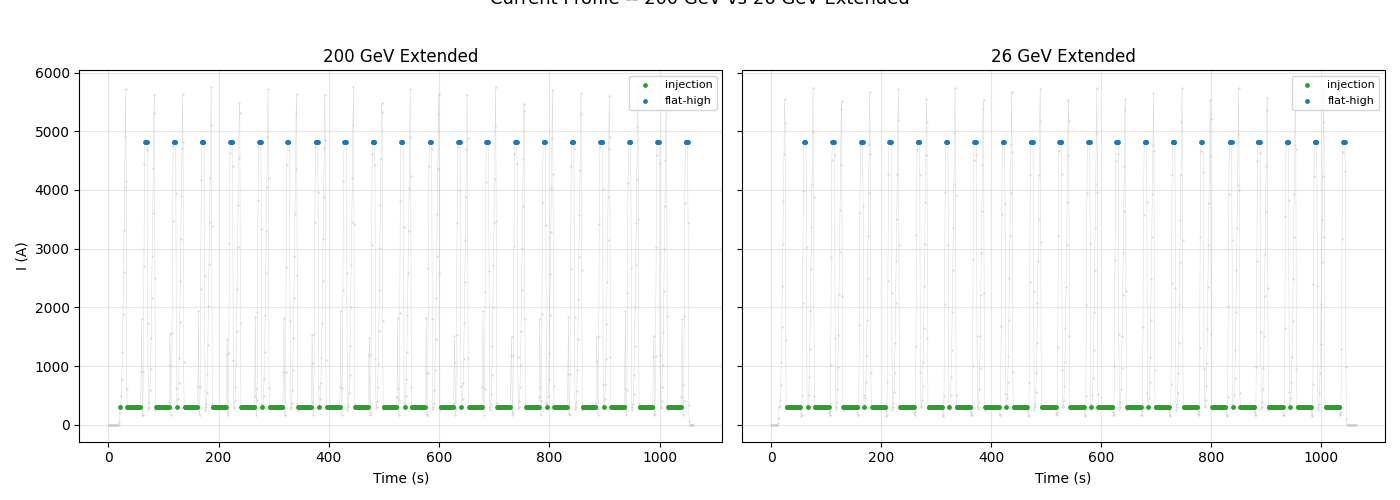

In [7]:
label_colors = {"injection": "tab:green", "flat-mid": "tab:purple", "flat-high": "tab:blue"}
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, t_m, I_m, lbl, plat, title in [
    (axes[0], t_200, I_200, lbl_200, plat_200, "200 GeV Extended"),
    (axes[1], t_26, I_26, lbl_26, plat_26, "26 GeV Extended")]:
    ax.plot(t_m, I_m, ".-", markersize=1, linewidth=0.3, color="lightgrey", zorder=0)
    for lab, col in label_colors.items():
        mask = lbl == lab; idx = np.where(mask)[0]
        if len(idx) > 0: ax.scatter(t_m[idx], I_m[idx], s=6, color=col, zorder=2, label=lab)
    ax.set_xlabel("Time (s)"); ax.set_title(title); ax.legend(fontsize=8, loc="upper right")
axes[0].set_ylabel("I (A)")
fig.suptitle("Current Profile -- 200 GeV vs 26 GeV Extended", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 7. Per-Supercycle Injection Harmonics

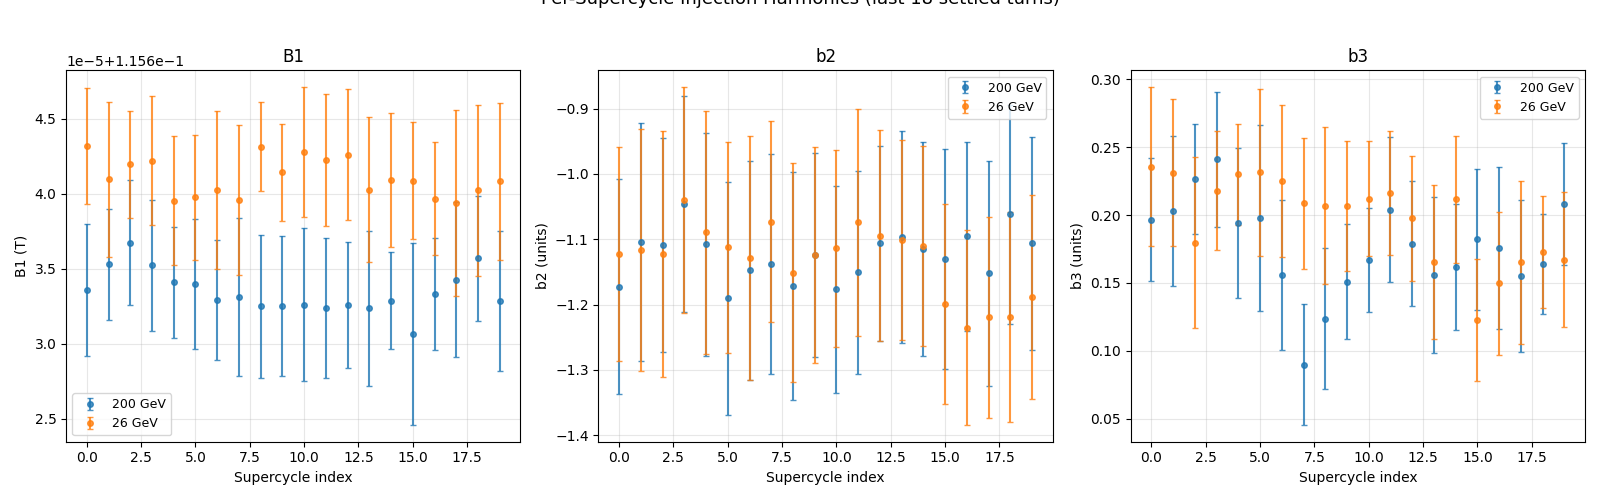

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
harmonics = [("B1_T", "B1 (T)"), ("b2_units", "b2 (units)"), ("b3_units", "b3 (units)")]
for ax, (col_name, ylabel) in zip(axes, harmonics):
    for ds_name, dfs, col in [("200 GeV", dfs_200, "tab:blue"), ("26 GeV", dfs_26, "tab:orange")]:
        inj = dfs[(dfs["label"] == "injection") & dfs["ok_main"]]
        if len(inj) == 0: continue
        sc_avg = inj.groupby("sc_idx")[col_name].agg(["mean", "std"]).reset_index()
        ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                    fmt="o", markersize=4, capsize=2, color=col, alpha=0.8, label=ds_name)
    ax.set_xlabel("Supercycle index"); ax.set_ylabel(ylabel); ax.legend(fontsize=9)
axes[0].set_title("B1"); axes[1].set_title("b2"); axes[2].set_title("b3")
fig.suptitle(f"Per-Supercycle Injection Harmonics (last {N_LAST_TURNS_INJ} settled turns)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 7b. Eddy-Current Settling at Injection

### Theory

When the magnet current changes rapidly — here from the LHC pilot flat-top
(~5785 A) down to the injection plateau (~301 A) — **eddy currents** are
induced in every conductive loop that threads the changing flux (yoke
laminations, beam screen, coil wedges, end plates, etc.).  Each such loop
*i* has its own *L/R* time constant

$$\tau_i = \frac{L_i}{R_i}$$

and generates a transient field perturbation that decays exponentially.
The total eddy-current contribution to the main dipole field is therefore

$$\Delta B_1(t) = \sum_{i} A_i \, e^{-t / \tau_i}$$

where

| Symbol | Meaning |
|--------|---------|
| $t$ | time since the start of the injection plateau (s) |
| $A_i$ | amplitude of the *i*-th eddy-current component ($\mu$T) — the field it contributes at $t = 0$ |
| $\tau_i$ | decay time constant (s) of the *i*-th component |

**No offset term** appears because $\Delta B_1$ is defined as the deviation
from the settled (long-time) mean, so $\Delta B_1 \to 0$ by construction.

### Models tested

| Model | Expression | Free parameters |
|-------|------------|-----------------|
| **1-$\tau$** | $A_1 e^{-t/\tau_1}$ | 2 |
| **2-$\tau$** | $A_1 e^{-t/\tau_1} + A_2 e^{-t/\tau_2}$ | 4 |
| **3-$\tau$** | $A_1 e^{-t/\tau_1} + A_2 e^{-t/\tau_2} + A_3 e^{-t/\tau_3}$ | 6 |

The best model is selected by **R²** (coefficient of determination).
Overfitting is flagged when two $\tau$ values are within 20 % of each
other with opposite-sign amplitudes (near-degenerate pair).

### Physical interpretation

The initial field perturbation at $t = 0$ is

$$\Delta B_1(0) = \sum_i A_i$$

Each $A_i$ quantifies how much field the *i*-th eddy-current path
"injects" into the aperture.  Fast components ($\tau < 0.5$ s) are
typically associated with thin structures (beam screen, copper wedges);
slow components ($\tau \sim 2\text{--}5$ s) with the bulk yoke
laminations.

### Worked example — 200 GeV, 2-$\tau$ fit

The best fit gives

$$\Delta B_1(t) = \underbrace{-5.1 \;\mu\text{T}}_{\text{fast}} \cdot e^{-t/0.035\,\text{s}} \;+\; \underbrace{-17.2 \;\mu\text{T}}_{\text{slow}} \cdot e^{-t/2.48\,\text{s}}$$

i.e. at the moment the current settles on the injection plateau, eddy
currents add $\Delta B_1(0) = -22.3\;\mu$T ($\approx -193$ ppm of
$B_1 = 115.6$ mT) to the dipole field.  The two components then decay
at very different rates:

| $t$ (s) | Fast ($\tau = 0.035$ s) | Slow ($\tau = 2.48$ s) | **Total** | % of $\Delta B_1(0)$ |
|--------:|------------------------:|-----------------------:|----------:|---------------------:|
| 0.0 | $-5.1\;\mu$T | $-17.2\;\mu$T | $-22.3\;\mu$T | 100 % |
| 0.035 | $-1.9\;\mu$T | $-17.0\;\mu$T | $-18.8\;\mu$T | 84 % |
| 0.1 | $-0.3\;\mu$T | $-16.5\;\mu$T | $-16.8\;\mu$T | 75 % |
| 1.0 | $\approx 0$ | $-11.5\;\mu$T | $-11.5\;\mu$T | 52 % |
| 2.0 | $\approx 0$ | $-7.7\;\mu$T | $-7.7\;\mu$T | 35 % |
| 5.0 | $\approx 0$ | $-2.3\;\mu$T | $-2.3\;\mu$T | 10 % |
| 7.1 | $\approx 0$ | $-1.0\;\mu$T | $-1.0\;\mu$T | 4.5 % |
| 10 | $\approx 0$ | $-0.3\;\mu$T | $-0.3\;\mu$T | 1.4 % |

**Key observations:**

- The **fast component** ($\tau_1 = 35$ ms, $A_1 = -5.1\;\mu$T) decays
  within a fraction of one turn — we cannot resolve it with 1 s sampling,
  so its amplitude is effectively an extrapolation.  It likely originates
  from thin conductive structures (beam screen, wedge copper).
- The **slow component** ($\tau_2 = 2.48$ s, $A_2 = -17.2\;\mu$T)
  dominates the visible settling.  It carries 77 % of the initial
  perturbation and takes $\sim 3\tau = 7.4$ s to drop below 5 % of
  $\Delta B_1(0)$.  This is consistent with eddy currents in the bulk
  yoke laminations.
- The settling cut-off (`N_LAST_TURNS_INJ = 18`, skipping the first
  $\sim 5$ turns) leaves a residual $\sim 2.3\;\mu$T — well within the
  turn-to-turn measurement noise ($\sigma \approx 5\;\mu$T).
- The 26 GeV dataset gives similar time constants ($\tau_1 = 37$ ms,
  $\tau_2 = 3.02$ s) with a slightly smaller initial perturbation
  ($\Delta B_1(0) = -19.6\;\mu$T), consistent with the same magnet
  under a different excitation history.

### Layout (2×2)

- **Top-left / top-right**: individual SC traces + mean ± std (200 GeV | 26 GeV)
- **Bottom-left**: overlay of both datasets' mean ± std
- **Bottom-right**: best multi-$\tau$ exponential fit with component breakdown

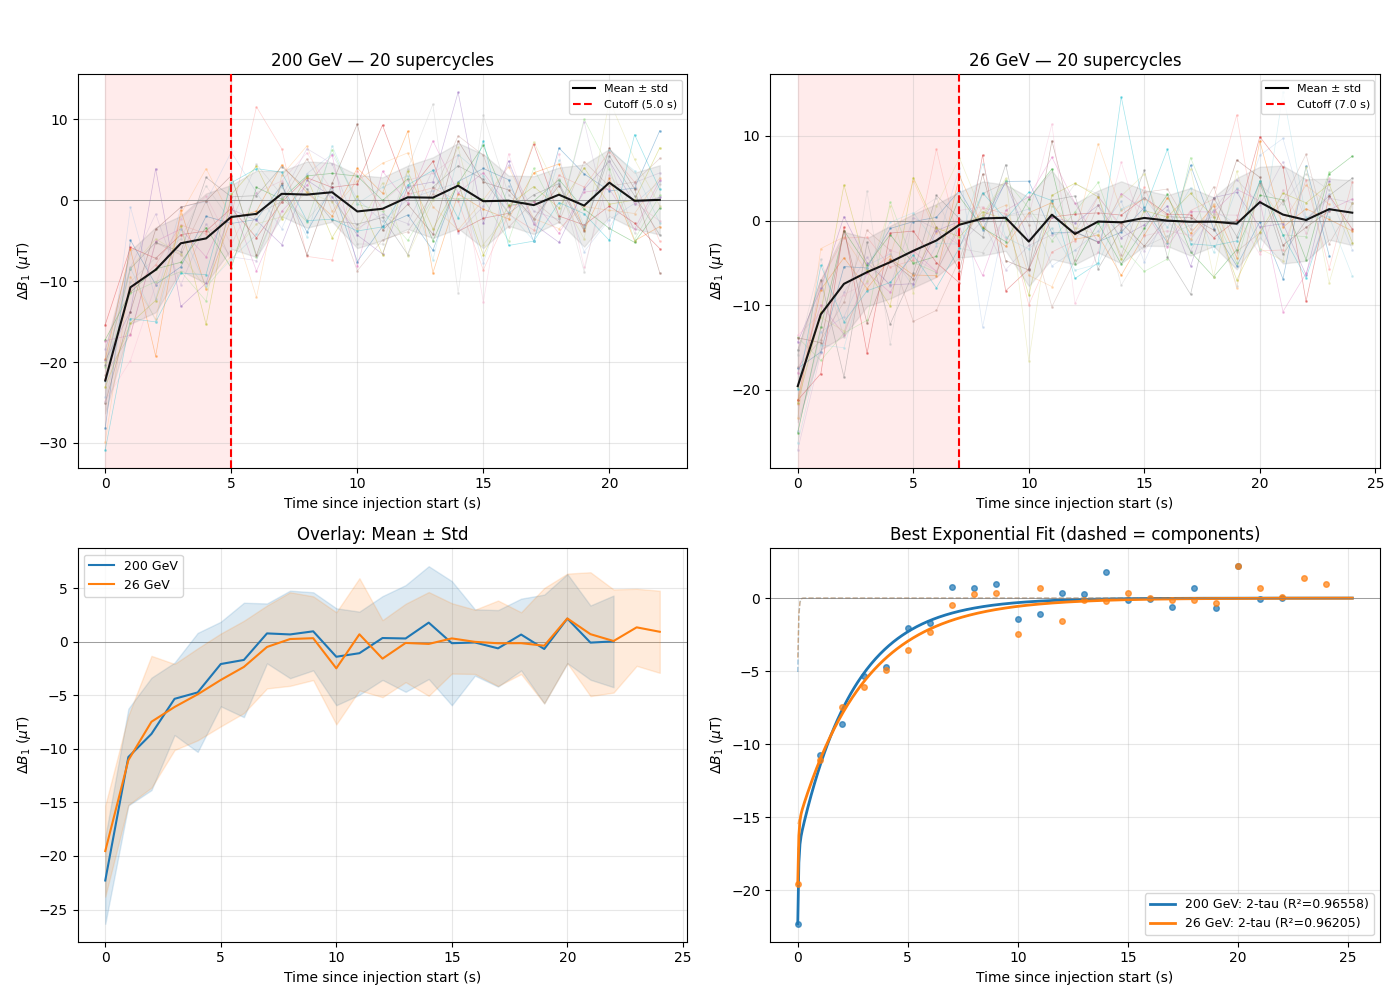


  200 GeV  (T_turn = 1.000 s)
  Model            R²  Notes
  --------------------------------------------------------------------------
  1-tau      0.957880
           Component 1: A =    -21.4 µT (+100.0% of dB1(0)),  tau = 2.037 s (2.04 turns)
           => dB1(0) = -21.4 µT  (total initial perturbation)

  2-tau      0.965575  << BEST
           Component 1: A =     -5.1 µT ( +22.7% of dB1(0)),  tau = 0.035 s (0.04 turns)
           Component 2: A =    -17.2 µT ( +77.3% of dB1(0)),  tau = 2.484 s (2.48 turns)
           => dB1(0) = -22.3 µT  (total initial perturbation)

  3-tau      0.970576  [OVERFIT: degenerate tau pair]
           Component 1: A =     -6.4 µT ( +28.9% of dB1(0)),  tau = 0.042 s (0.04 turns)
           Component 2: A =   -813.0 µT (+3647.0% of dB1(0)),  tau = 4.511 s (4.51 turns)
           Component 3: A =   +797.1 µT (-3575.9% of dB1(0)),  tau = 4.556 s (4.56 turns)
           => dB1(0) = -22.3 µT  (total initial perturbation)


  26 GeV  (T_turn = 1.000 s)
 

In [9]:
# ---- Eddy-current settling at injection: dB1 per turn within supercycle ----
from matplotlib.lines import Line2D
from scipy.optimize import curve_fit
import warnings

# ---- Exponential models (no offset — dB1 → 0 by construction) ----
def exp1(t, A1, tau1):
    return A1 * np.exp(-t / tau1)

def exp2(t, A1, tau1, A2, tau2):
    return A1 * np.exp(-t / tau1) + A2 * np.exp(-t / tau2)

def exp3(t, A1, tau1, A2, tau2, A3, tau3):
    return A1 * np.exp(-t / tau1) + A2 * np.exp(-t / tau2) + A3 * np.exp(-t / tau3)

MODELS = [
    ("1-tau", exp1, [100.0, 2.0]),
    ("2-tau", exp2, [80.0, 1.0, 20.0, 5.0]),
    ("3-tau", exp3, [60.0, 0.5, 30.0, 2.0, 10.0, 8.0]),
]

def compute_turn_period(df_full):
    """Median time between consecutive injection turns within the same SC."""
    inj = df_full[(df_full["label"] == "injection") & (df_full["sc_idx"] >= 0)].copy()
    inj = inj.sort_values("global_turn")
    dt_all = []
    for sc_id in inj["sc_idx"].unique():
        sub = inj[inj["sc_idx"] == sc_id].sort_values("global_turn")
        dt = np.diff(sub["time_s"].values)
        dt_all.extend(dt[(dt > 0.1) & (dt < 5.0)])  # within-SC only
    return float(np.median(dt_all)) if dt_all else 1.0

def collect_dB1_traces(df_full):
    """Collect per-SC dB1 traces, filtering by MIN_SC_TURNS and trimming ends."""
    inj = df_full[(df_full["label"] == "injection") & df_full["ok_main"]].copy()
    inj = inj[inj["sc_idx"] >= 0]
    sc_ids = sorted(inj["sc_idx"].unique())

    all_dB1 = {}          # turn_idx -> list of dB1 (µT)
    per_sc_traces = []     # list of (turn_idx_array, dB1_array)
    n_skip_values = []

    for sc_id in sc_ids:
        sub = inj[inj["sc_idx"] == sc_id].sort_values("global_turn").reset_index(drop=True)
        if len(sub) < MIN_SC_TURNS:
            continue
        if N_SKIP_END_SC > 0 and len(sub) > N_SKIP_END_SC + 2:
            sub = sub.iloc[:-N_SKIP_END_SC]
        n_turns_sc = len(sub)
        turn_idx = np.arange(n_turns_sc)
        n_last = min(N_LAST_TURNS_INJ, n_turns_sc)
        n_skip = n_turns_sc - n_last
        n_skip_values.append(n_skip)
        settled_mean = sub["B1_T"].iloc[-n_last:].mean()
        dB1_uT = (sub["B1_T"].values - settled_mean) * 1e6
        per_sc_traces.append((turn_idx, dB1_uT))
        for t, val in zip(turn_idx, dB1_uT):
            all_dB1.setdefault(t, []).append(val)

    turns_sorted = np.array(sorted(all_dB1.keys()))
    mean_vals = np.array([np.mean(all_dB1[t]) for t in turns_sorted])
    std_vals  = np.array([np.std(all_dB1[t])  for t in turns_sorted])
    n_skip_typical = int(np.median(n_skip_values)) if n_skip_values else 0

    return per_sc_traces, turns_sorted, mean_vals, std_vals, n_skip_typical

def fit_models_seconds(t_seconds, mean_vals, T_turn):
    """Fit 1/2/3-tau models in seconds. Returns list of (name, func, popt, R²)."""
    ss_tot = np.sum((mean_vals - mean_vals.mean()) ** 2)
    # Scale initial guesses to seconds
    models_s = [
        ("1-tau", exp1, [100.0, 2.0 * T_turn]),
        ("2-tau", exp2, [80.0, 1.0 * T_turn, 20.0, 5.0 * T_turn]),
        ("3-tau", exp3, [60.0, 0.5 * T_turn, 30.0, 2.0 * T_turn, 10.0, 8.0 * T_turn]),
    ]
    results = []
    for name, func, p0 in models_s:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore", RuntimeWarning)
                warnings.simplefilter("ignore")
                popt, _ = curve_fit(func, t_seconds, mean_vals, p0=p0,
                                    maxfev=20000, method="lm")
            residuals = mean_vals - func(t_seconds, *popt)
            ss_res = np.sum(residuals ** 2)
            r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 0.0
            results.append((name, func, popt, r2))
        except RuntimeError:
            results.append((name, func, None, -1.0))
    return results

def detect_overfitting(popt):
    """Check for degenerate tau pairs (within 20%, opposite-sign amplitudes)."""
    n_comp = len(popt) // 2
    if n_comp < 2:
        return False
    taus = [(popt[2*i], popt[2*i+1]) for i in range(n_comp)]  # (A, tau) pairs
    for i in range(n_comp):
        for j in range(i+1, n_comp):
            Ai, ti = taus[i]
            Aj, tj = taus[j]
            tau_avg = 0.5 * (abs(ti) + abs(tj))
            if tau_avg > 0 and abs(ti - tj) / tau_avg < 0.2:
                if Ai * Aj < 0:  # opposite signs
                    return True
    return False

# ---- Collect traces and fit for both datasets ----
datasets = [
    ("200 GeV", df_200, "tab:blue"),
    ("26 GeV",  df_26,  "tab:orange"),
]

collected = {}
for ds_name, df_full, color in datasets:
    T_turn = compute_turn_period(df_full)
    traces, turns, mean_v, std_v, n_skip = collect_dB1_traces(df_full)
    t_seconds = turns.astype(float) * T_turn
    fit_res = fit_models_seconds(t_seconds, mean_v, T_turn)
    # Best R², but flag overfitting
    r2_vals = [r[3] for r in fit_res]
    best_idx = int(np.argmax(r2_vals))
    # If best is overfit, fall back to simpler
    if fit_res[best_idx][2] is not None and detect_overfitting(fit_res[best_idx][2]):
        for fallback in range(best_idx - 1, -1, -1):
            if fit_res[fallback][2] is not None and not detect_overfitting(fit_res[fallback][2]):
                best_idx = fallback
                break
    collected[ds_name] = dict(
        traces=traces, turns=turns, t_seconds=t_seconds,
        mean=mean_v, std=std_v, n_skip=n_skip,
        fits=fit_res, best_idx=best_idx, color=color, T_turn=T_turn,
    )

# ---- 2×2 figure ----
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Row 0: individual SC traces + mean ± std (one panel per dataset)
for col_idx, (ds_name, _, color) in enumerate(datasets):
    ax = axes[0, col_idx]
    d = collected[ds_name]
    cmap = plt.cm.tab20(np.linspace(0, 1, max(len(d["traces"]), 1)))
    for i, (tidx, dB1) in enumerate(d["traces"]):
        t_s = tidx.astype(float) * d["T_turn"]
        ax.plot(t_s, dB1, ".-", markersize=2, linewidth=0.5, alpha=0.4,
                color=cmap[i % len(cmap)])
    ax.plot(d["t_seconds"], d["mean"], "k-", linewidth=1.5, alpha=0.9, zorder=10)
    ax.fill_between(d["t_seconds"], d["mean"] - d["std"], d["mean"] + d["std"],
                    alpha=0.15, color="grey", zorder=9)
    skip_t = d["n_skip"] * d["T_turn"]
    ax.axvline(skip_t, color="red", ls="--", lw=1.5, zorder=5)
    ax.axvspan(0, skip_t, alpha=0.08, color="red", zorder=0)
    ax.axhline(0, color="grey", lw=0.5)
    ax.set_xlabel("Time since injection start (s)")
    ax.set_ylabel(r"$\Delta B_1$ ($\mu$T)")
    ax.set_title(f"{ds_name} — {len(d['traces'])} supercycles")
    ax.legend(
        [Line2D([0], [0], color="k", lw=1.5),
         Line2D([0], [0], color="red", ls="--", lw=1.5)],
        ["Mean ± std", f"Cutoff ({skip_t:.1f} s)"],
        fontsize=8, loc="upper right",
    )

# (1,0): Overlay — both datasets' mean ± std
ax = axes[1, 0]
for ds_name, _, color in datasets:
    d = collected[ds_name]
    ax.plot(d["t_seconds"], d["mean"], "-", lw=1.5, color=color, label=ds_name, zorder=10)
    ax.fill_between(d["t_seconds"], d["mean"] - d["std"], d["mean"] + d["std"],
                    alpha=0.15, color=color, zorder=9)
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("Time since injection start (s)")
ax.set_ylabel(r"$\Delta B_1$ ($\mu$T)")
ax.set_title("Overlay: Mean ± Std")
ax.legend(fontsize=9)

# (1,1): Best fit — mean data + individual component curves
ax = axes[1, 1]
t_max_s = max(d["t_seconds"][-1] for d in collected.values())
t_fine = np.linspace(0, t_max_s * 1.05, 500)

for ds_name, _, color in datasets:
    d = collected[ds_name]
    ax.plot(d["t_seconds"], d["mean"], "o", markersize=4, color=color, alpha=0.7)
    best = d["fits"][d["best_idx"]]
    bname, bfunc, bpopt, br2 = best
    if bpopt is not None:
        # Total fit curve
        ax.plot(t_fine, bfunc(t_fine, *bpopt), "-", lw=2, color=color,
                label=f"{ds_name}: {bname} (R²={br2:.5f})")
        # Individual components (dashed)
        n_comp = len(bpopt) // 2
        if n_comp > 1:
            for k in range(n_comp):
                Ak, tauk = bpopt[2*k], bpopt[2*k+1]
                ax.plot(t_fine, Ak * np.exp(-t_fine / tauk), "--", lw=1,
                        color=color, alpha=0.4)

ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("Time since injection start (s)")
ax.set_ylabel(r"$\Delta B_1$ ($\mu$T)")
ax.set_title("Best Exponential Fit (dashed = components)")
ax.legend(fontsize=9)

fig.suptitle("Eddy-Current Settling at Injection — $\\Delta B_1$", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ---- Text summary: R² comparison, parameters in seconds, component breakdown ----
for ds_name, _, _ in datasets:
    d = collected[ds_name]
    T = d["T_turn"]
    print(f"\n{'='*78}")
    print(f"  {ds_name}  (T_turn = {T:.3f} s)")
    print(f"{'='*78}")
    print(f"  {'Model':<8s} {'R²':>10s}  {'Notes'}")
    print(f"  {'-'*74}")

    for i, (name, func, popt, r2) in enumerate(d["fits"]):
        is_best = (i == d["best_idx"])
        marker = "  << BEST" if is_best else ""
        overfit = ""
        if popt is not None and detect_overfitting(popt):
            overfit = "  [OVERFIT: degenerate tau pair]"

        if popt is None:
            print(f"  {name:<8s} {'FAILED':>10s}")
            continue

        print(f"  {name:<8s} {r2:>10.6f}{marker}{overfit}")
        n_comp = len(popt) // 2
        dB1_0 = sum(popt[2*k] for k in range(n_comp))
        for k in range(n_comp):
            Ak = popt[2*k]
            tauk = popt[2*k+1]
            frac = 100.0 * Ak / dB1_0 if abs(dB1_0) > 1e-12 else 0.0
            print(f"           Component {k+1}: A = {Ak:+8.1f} µT "
                  f"({frac:+6.1f}% of dB1(0)),  "
                  f"tau = {tauk:.3f} s ({tauk/T:.2f} turns)")
        print(f"           => dB1(0) = {dB1_0:+.1f} µT  (total initial perturbation)")
        print()


---
## 8. SFTPRO Flat-Top: Effect of Preceding MD1

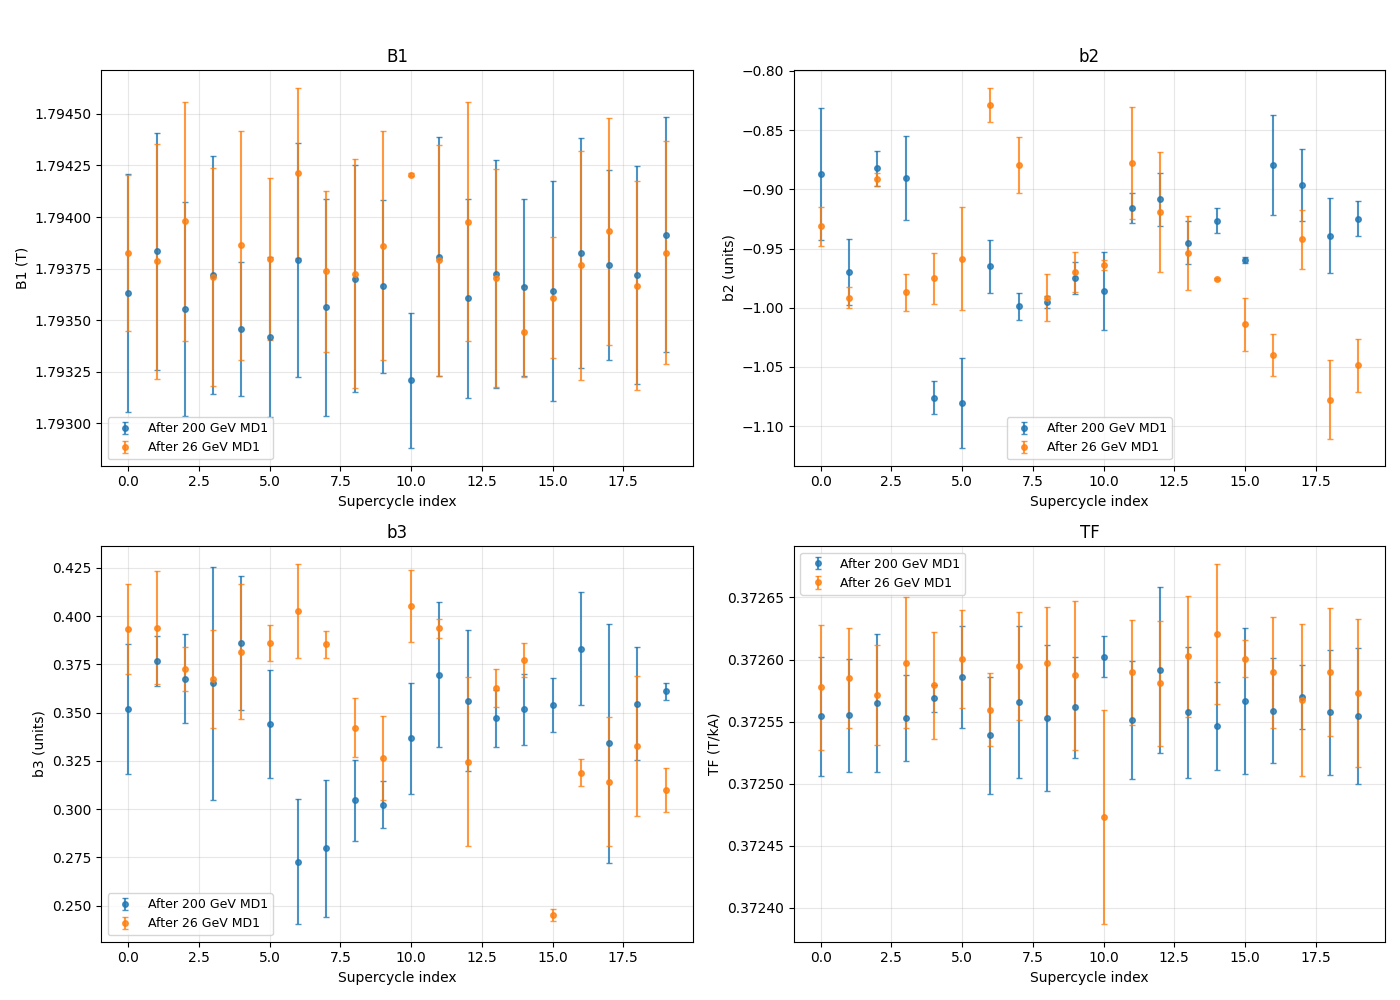

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col_name, ylabel) in zip(axes.ravel(),
    [("B1_T", "B1 (T)"), ("b2_units", "b2 (units)"), ("b3_units", "b3 (units)"), ("TF_TperkA", "TF (T/kA)")]):
    for ds_name, dfs, col in [("After 200 GeV MD1", dfs_200, "tab:blue"), ("After 26 GeV MD1", dfs_26, "tab:orange")]:
        fh = dfs[(dfs["label"] == "flat-high") & dfs["ok_main"]].copy()
        if len(fh) == 0: continue
        if col_name == "TF_TperkA": fh["TF_TperkA"] = fh["B1_T"] / (fh["I_mean_A"] / 1000.0)
        sc_avg = fh.groupby("sc_idx")[col_name].agg(["mean", "std"]).reset_index()
        ax.errorbar(sc_avg["sc_idx"], sc_avg["mean"], yerr=sc_avg["std"],
                    fmt="o", markersize=4, capsize=2, color=col, alpha=0.8, label=ds_name)
    ax.set_xlabel("Supercycle index"); ax.set_ylabel(ylabel); ax.legend(fontsize=9)
axes[0,0].set_title("B1"); axes[0,1].set_title("b2"); axes[1,0].set_title("b3"); axes[1,1].set_title("TF")
fig.suptitle("SFTPRO Flat-Top: After 200 GeV MD1 vs After 26 GeV MD1", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 9. Summary Statistics

In [11]:
summary_rows = []
for ds_name, dfs in [("200 GeV", dfs_200), ("26 GeV", dfs_26)]:
    for lab, desc in [("injection", "Injection (MD1)"), ("flat-high", "Top of SFTPRO")]:
        sub = dfs[(dfs["label"] == lab) & dfs["ok_main"]]
        if len(sub) == 0: continue
        tf = sub["B1_T"].mean() / (sub["I_mean_A"].mean() / 1000.0)
        summary_rows.append({
            "Dataset": ds_name, "Operating point": desc, "N turns": len(sub),
            "I mean (A)": f"{sub['I_mean_A'].mean():.1f}",
            "B1 mean (T)": f"{sub['B1_T'].mean():.6f}", "B1 std (T)": f"{sub['B1_T'].std():.6f}",
            "b2 mean": f"{sub['b2_units'].mean():+.4f}", "b2 std": f"{sub['b2_units'].std():.4f}",
            "b3 mean": f"{sub['b3_units'].mean():+.4f}", "b3 std": f"{sub['b3_units'].std():.4f}",
            "TF (T/kA)": f"{tf:.4f}",
        })
df_summary = pd.DataFrame(summary_rows)
print(f"[Settled data: last {N_LAST_TURNS_INJ} injection turns per supercycle]\n")
print(df_summary.to_string(index=False))

[Settled data: last 18 injection turns per supercycle]

Dataset Operating point  N turns I mean (A) B1 mean (T) B1 std (T) b2 mean b2 std b3 mean b3 std TF (T/kA)
200 GeV Injection (MD1)      360      300.9    0.115633   0.000005 -1.1251 0.1650 +0.1766 0.0598    0.3843
200 GeV   Top of SFTPRO       72     4814.5    1.793681   0.000472 -0.9445 0.0576 +0.3447 0.0418    0.3726
 26 GeV Injection (MD1)      360      300.9    0.115641   0.000005 -1.1318 0.1694 +0.1977 0.0585    0.3843
 26 GeV   Top of SFTPRO       69     4814.5    1.793817   0.000462 -0.9643 0.0636 +0.3554 0.0418    0.3726


---
## 10. B1, b2, b3 Comparison Plots

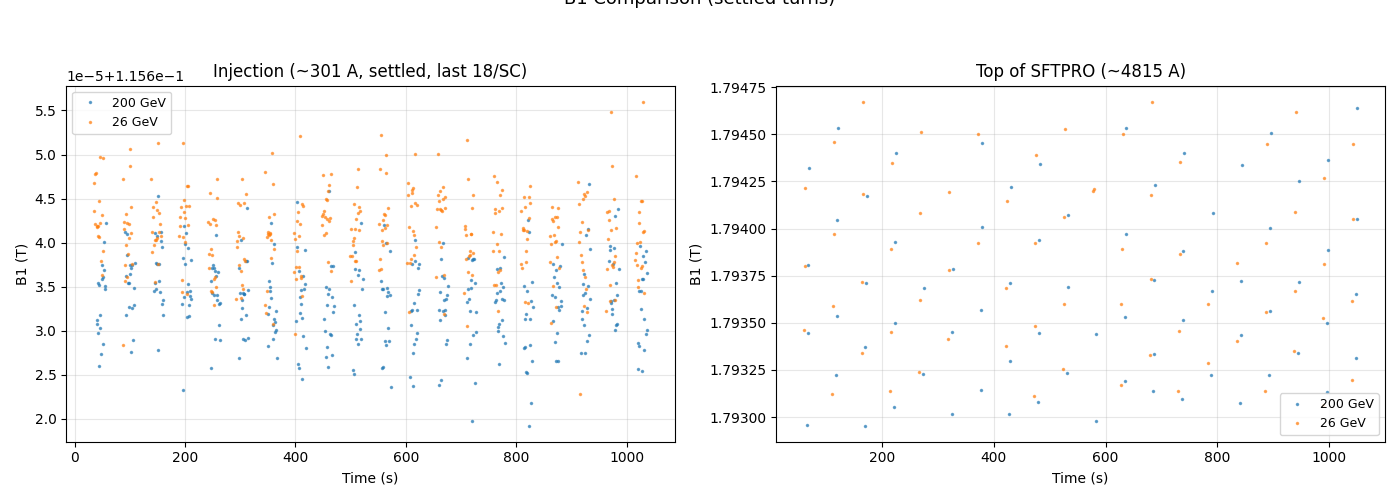

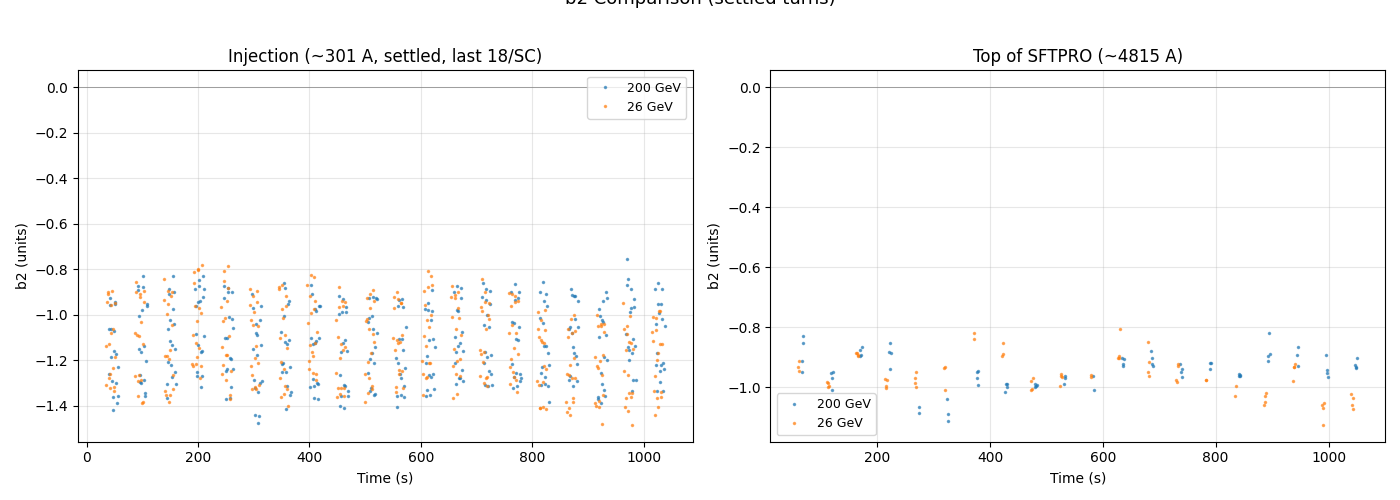

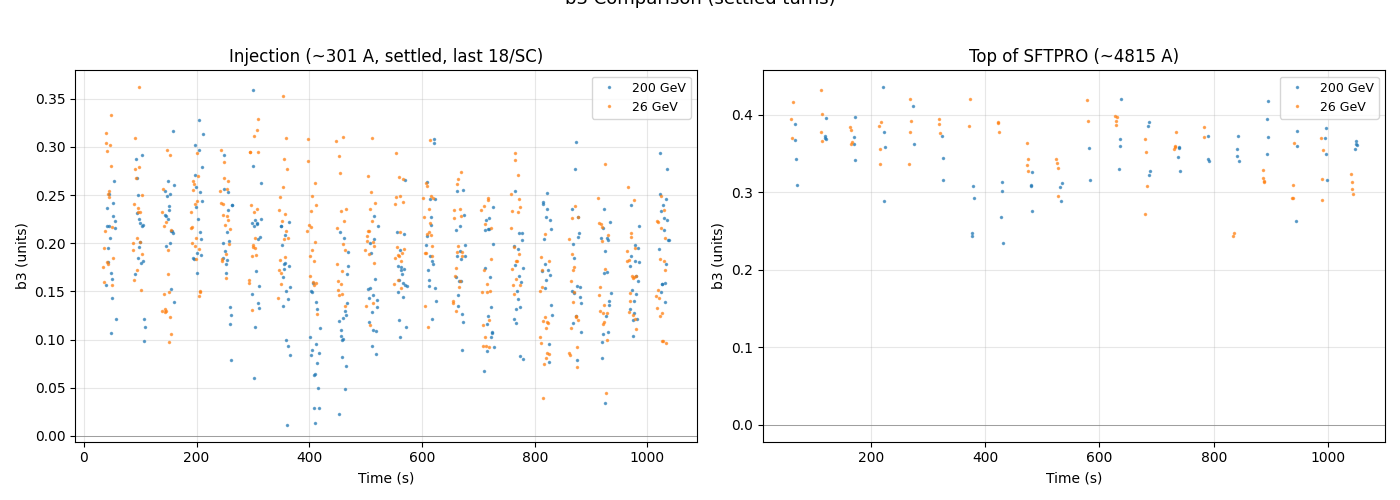

In [12]:
for harm_name, harm_col, ylabel in [("B1", "B1_T", "B1 (T)"), ("b2", "b2_units", "b2 (units)"), ("b3", "b3_units", "b3 (units)")]:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, lab, title in [
        (axes[0], "injection", f"Injection (~301 A, settled, last {N_LAST_TURNS_INJ}/SC)"),
        (axes[1], "flat-high", "Top of SFTPRO (~4815 A)")]:
        for ds_name, dfs, col in [("200 GeV", dfs_200, "tab:blue"), ("26 GeV", dfs_26, "tab:orange")]:
            sub = dfs[(dfs["label"] == lab) & dfs["ok_main"]]
            if len(sub) == 0: continue
            ax.plot(sub["time_s"].values, sub[harm_col].values, ".", markersize=3, alpha=0.6, color=col, label=ds_name)
        if harm_col != "B1_T": ax.axhline(0, color="grey", linewidth=0.5)
        ax.set_xlabel("Time (s)"); ax.set_ylabel(ylabel); ax.set_title(title); ax.legend(fontsize=9)
    fig.suptitle(f"{harm_name} Comparison (settled turns)", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()

---
## 11. Box Plots

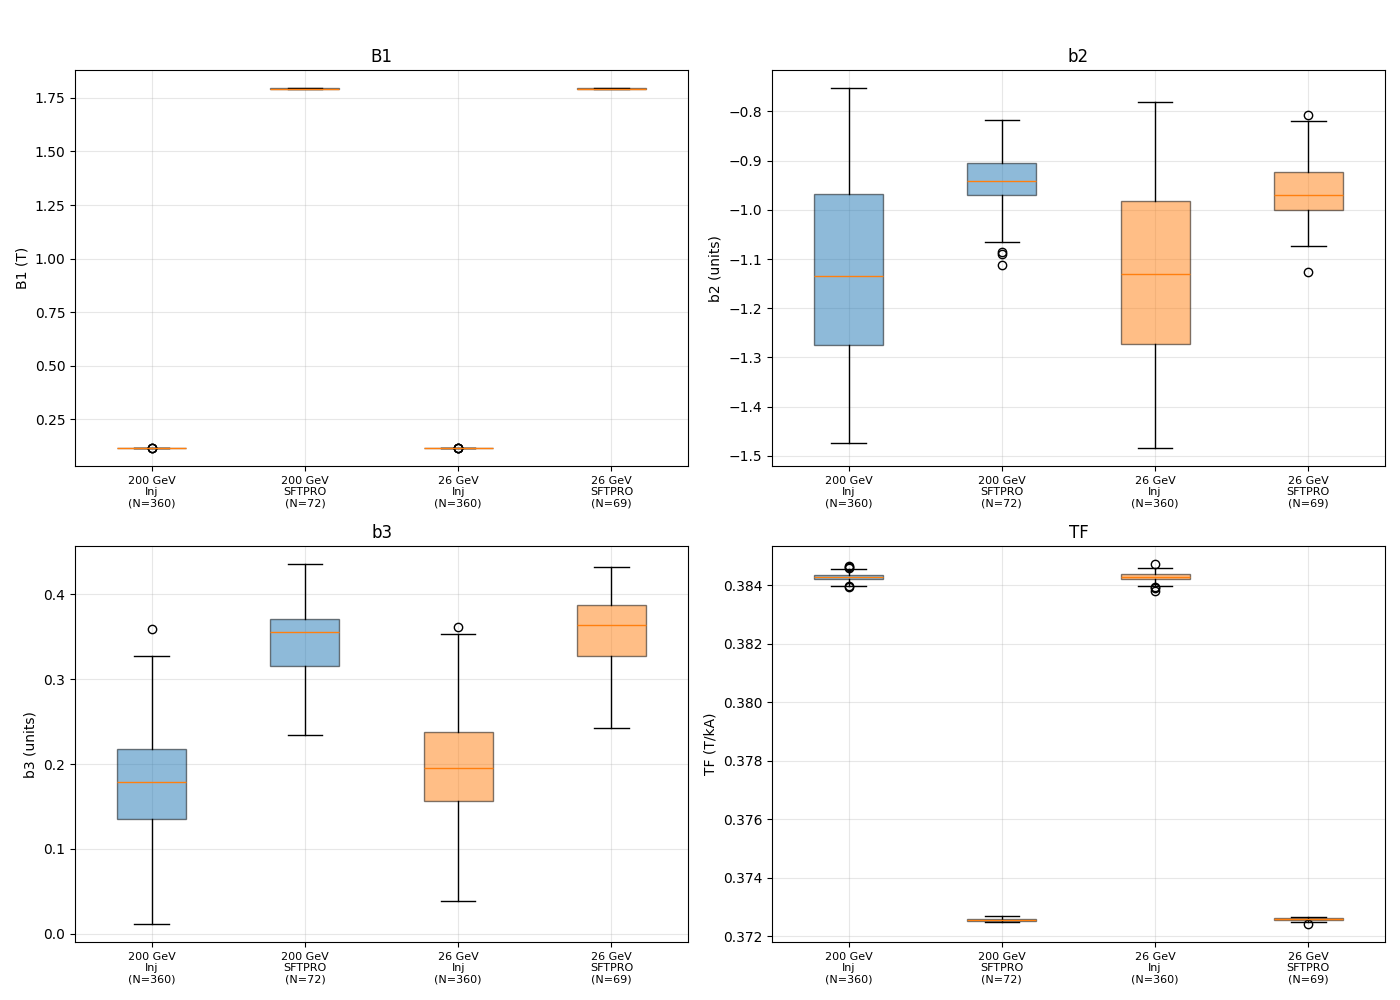

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (col_name, ylabel, title) in zip(axes.ravel(),
    [("B1_T", "B1 (T)", "B1"), ("b2_units", "b2 (units)", "b2"),
     ("b3_units", "b3 (units)", "b3"), ("TF_TperkA", "TF (T/kA)", "TF")]):
    box_data, box_labels, box_colors = [], [], []
    for ds_name, dfs, base_col in [("200 GeV", dfs_200, "tab:blue"), ("26 GeV", dfs_26, "tab:orange")]:
        for lab, short in [("injection", "Inj"), ("flat-high", "SFTPRO")]:
            sub = dfs[(dfs["label"] == lab) & dfs["ok_main"]].copy()
            if len(sub) == 0: continue
            vals = (sub["B1_T"] / (sub["I_mean_A"] / 1000.0)).values if col_name == "TF_TperkA" else sub[col_name].values
            box_data.append(vals); box_labels.append(f"{ds_name}\n{short}\n(N={len(sub)})"); box_colors.append(base_col)
    if box_data:
        bp = ax.boxplot(box_data, tick_labels=box_labels, patch_artist=True)
        for patch, col in zip(bp["boxes"], box_colors): patch.set_facecolor(col); patch.set_alpha(0.5)
    ax.set_ylabel(ylabel); ax.set_title(title); ax.tick_params(axis="x", labelsize=8)
fig.suptitle("Distribution Comparison (settled turns)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

---
## 12. Statistical Significance

Sigma = |diff| / sqrt(std1^2/N1 + std2^2/N2). > 3 sigma = real difference.

In [14]:
print(f"Difference: (200 GeV) - (26 GeV)  [settled, last {N_LAST_TURNS_INJ}/SC at injection]")
print("=" * 100)
results = []
for lab, desc in [("injection", "Injection (~301 A)"), ("flat-high", "SFTPRO (~4815 A)")]:
    s200 = dfs_200[(dfs_200["label"] == lab) & dfs_200["ok_main"]]
    s26 = dfs_26[(dfs_26["label"] == lab) & dfs_26["ok_main"]]
    if len(s200) == 0 or len(s26) == 0: continue

    dB1 = s200["B1_T"].mean() - s26["B1_T"].mean()
    db2 = s200["b2_units"].mean() - s26["b2_units"].mean()
    db3 = s200["b3_units"].mean() - s26["b3_units"].mean()
    tf200 = s200["B1_T"].mean() / (s200["I_mean_A"].mean() / 1000.0)
    tf26 = s26["B1_T"].mean() / (s26["I_mean_A"].mean() / 1000.0)
    dTF = tf200 - tf26

    dB1_err = np.sqrt((s200["B1_T"].std()**2/len(s200)) + (s26["B1_T"].std()**2/len(s26)))
    db2_err = np.sqrt((s200["b2_units"].std()**2/len(s200)) + (s26["b2_units"].std()**2/len(s26)))
    db3_err = np.sqrt((s200["b3_units"].std()**2/len(s200)) + (s26["b3_units"].std()**2/len(s26)))
    tf200_vals = s200["B1_T"] / (s200["I_mean_A"] / 1000.0)
    tf26_vals = s26["B1_T"] / (s26["I_mean_A"] / 1000.0)
    dTF_err = np.sqrt((tf200_vals.std()**2/len(s200)) + (tf26_vals.std()**2/len(s26)))

    sig_B1 = abs(dB1)/dB1_err if dB1_err > 0 else 0
    sig_b2 = abs(db2)/db2_err if db2_err > 0 else 0
    sig_b3 = abs(db3)/db3_err if db3_err > 0 else 0
    sig_TF = abs(dTF)/dTF_err if dTF_err > 0 else 0

    print(f"{desc:>30s}  dB1={dB1:+.6f}+/-{dB1_err:.6f}  db2={db2:+.4f}+/-{db2_err:.4f}  "
          f"db3={db3:+.4f}+/-{db3_err:.4f}  dTF={dTF:+.4f}+/-{dTF_err:.4f}")
    print(f"{'(sigma)':>30s}  {sig_B1:>12.1f}  {sig_b2:>14.1f}  {sig_b3:>14.1f}  {sig_TF:>14.1f}")
    results.append((lab, desc, dB1, sig_B1, db2, sig_b2, db3, sig_b3, dTF, sig_TF, len(s200), len(s26)))

print("\nINTERPRETATION")
print("-" * 70)
for lab, desc, dB1, sB1, db2, sb2, db3, sb3, dTF, sTF, n200, n26 in results:
    print(f"\n  {desc}  (N: {n200} vs {n26} turns)")
    for name, diff, sig, unit in [("B1", dB1, sB1, "T"), ("b2", db2, sb2, "units"),
                                   ("b3", db3, sb3, "units"), ("TF", dTF, sTF, "T/kA")]:
        verdict = "REAL (>3 sigma)" if sig > 3 else ("suggestive (2-3 sigma)" if sig >= 2 else "no evidence (<2 sigma)")
        diff_str = f"{diff*1e6:+.1f} uT" if "T" in unit and "units" not in unit and "kA" not in unit else f"{diff:+.4f} {unit}"
        print(f"    {name:>3s}: {diff_str:>16s}  ({sig:.1f} sigma) -> {verdict}")

print("\nNOTE: high sigma = reliably detected, NOT necessarily large.")
print("Datasets measured ~30 min apart with different cycle histories.")

Difference: (200 GeV) - (26 GeV)  [settled, last 18/SC at injection]
            Injection (~301 A)  dB1=-0.000008+/-0.000000  db2=+0.0067+/-0.0125  db3=-0.0211+/-0.0044  dTF=-0.0000+/-0.0000
                       (sigma)          22.2             0.5             4.8             1.7
              SFTPRO (~4815 A)  dB1=-0.000136+/-0.000079  db2=+0.0198+/-0.0102  db3=-0.0107+/-0.0070  dTF=-0.0000+/-0.0000
                       (sigma)           1.7             1.9             1.5             2.8

INTERPRETATION
----------------------------------------------------------------------

  Injection (~301 A)  (N: 360 vs 360 turns)
     B1:          -7.6 uT  (22.2 sigma) -> REAL (>3 sigma)
     b2:    +0.0067 units  (0.5 sigma) -> no evidence (<2 sigma)
     b3:    -0.0211 units  (4.8 sigma) -> REAL (>3 sigma)
     TF:     -0.0000 T/kA  (1.7 sigma) -> no evidence (<2 sigma)

  SFTPRO (~4815 A)  (N: 72 vs 69 turns)
     B1:        -136.4 uT  (1.7 sigma) -> no evidence (<2 sigma)
     b2:    +0

---
## 12b. Hysteresis at Injection — B1 and b3

### Theory

In a ferromagnetic yoke the relationship between field $B$ and excitation
current $I$ is not single-valued: it depends on the **magnetic history**
(the $B$–$H$ hysteresis loop).  At any given operating current $I_0$, the
field $B(I_0)$ differs depending on whether the magnet was previously
excited to a higher or lower maximum current $I_\text{max}$.

For two measurement campaigns sharing the same injection current
($I_\text{inj} \approx 301$ A) but differing in the preceding cycle's
peak excitation:

| Campaign | Preceding peak | Expected remanent state |
|----------|---------------|------------------------|
| **200 GeV** | ~5785 A (LHC pilot) | Iron driven further into saturation → **larger** remanent $M_r$ → return branch sits **lower** on the $B$–$H$ plane |
| **26 GeV** | ~1700 A (26 GeV cycle) | Lower saturation → **smaller** remanent $M_r$ → return branch sits **higher** |

The **hysteresis width** at injection is defined as

$$\delta B_1^{\,\text{hyst}} = \langle B_1 \rangle_{200\,\text{GeV}} - \langle B_1 \rangle_{26\,\text{GeV}}$$

and similarly for the relative sextupole

$$\delta b_3^{\,\text{hyst}} = \langle b_3 \rangle_{200\,\text{GeV}} - \langle b_3 \rangle_{26\,\text{GeV}}$$

A negative $\delta B_1$ means the 200 GeV cycle produces a **lower** field
at injection — consistent with the deeper-saturation return branch.

### Analysis below

Only quantities with **> 3 sigma significance** from Section 12 are
analysed here:
- **B1** at injection: 22.2 sigma
- **b3** at injection: 4.8 sigma

Per-supercycle matching quantifies cycle-to-cycle stability of the
hysteresis offset.

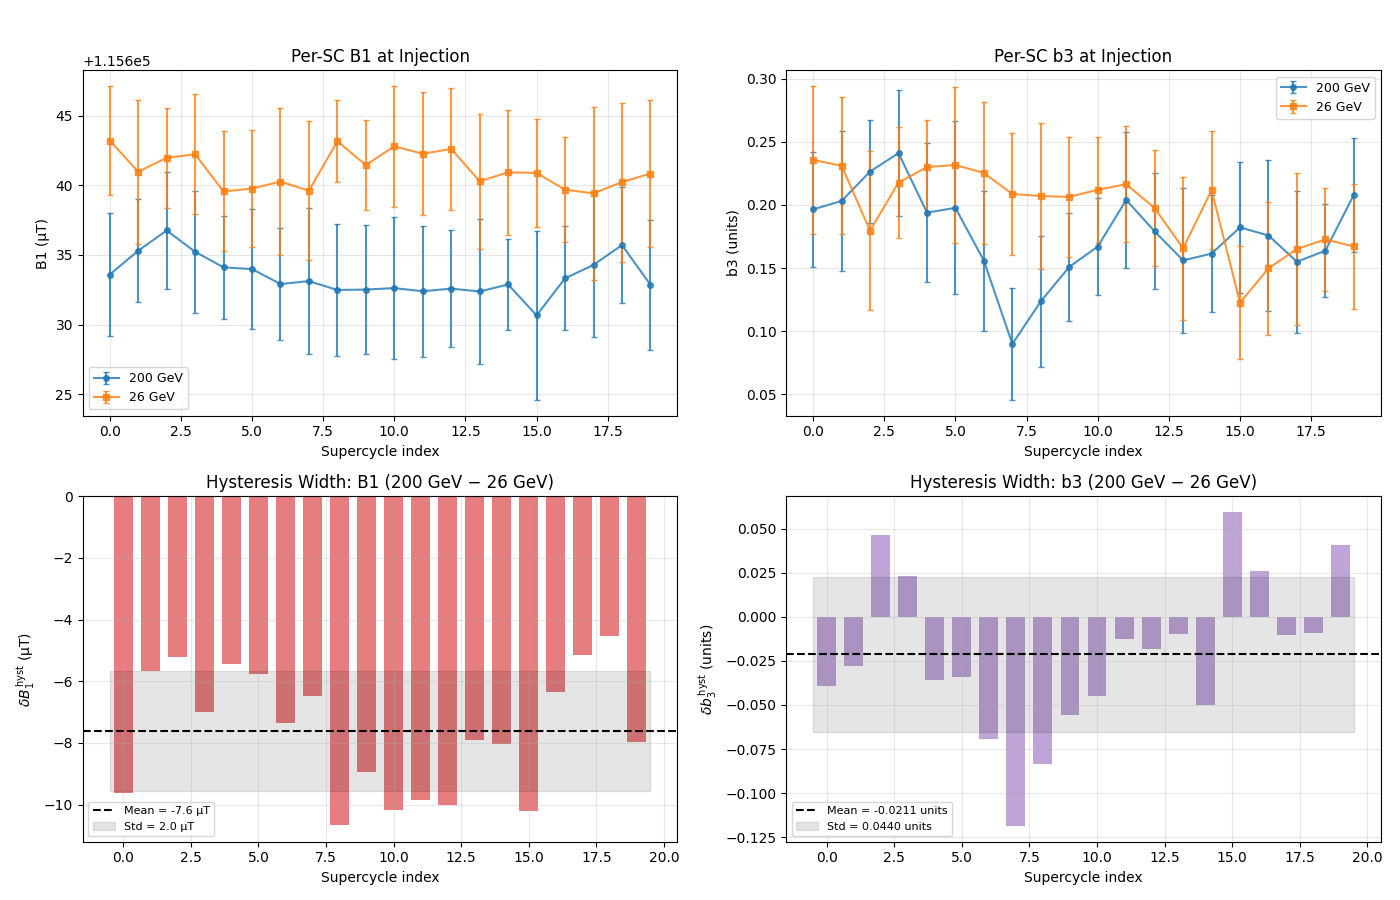


  Hysteresis at Injection (~301 A)
  Only quantities with > 3 sigma significance
  Matched supercycles: 20

  B1 (main dipole field):
    200 GeV mean B1 = 115.6335 mT
     26 GeV mean B1 = 115.6411 mT
    delta B1 (hyst) = -7.6 ± 2.0 µT  (per-SC matched)
    Relative:         -66 ppm of B1
    Sign: 200 GeV field is lower (deeper-saturation return branch)

  b3 (relative normal sextupole):
    200 GeV mean b3 = +0.1766 units
     26 GeV mean b3 = +0.1977 units
    delta b3 (hyst) = -0.0211 ± 0.0440 units  (per-SC matched)

  Stability (per-SC std / |mean|):
    B1: 26%  (low = reproducible offset)
    b3: 209%  (low = reproducible offset)

  INTERPRETATION:
    The hysteresis width is small but reproducible across 20 SCs.
    The B1 offset (-7.6 µT ≈ 66 ppm) reflects the
    different remanent magnetisation from the 200 GeV vs 26 GeV cycle.
    The b3 offset (-0.0211 units) indicates a small
    sextupole component sensitive to the preceding excitation history.


In [15]:
# ---- 12b. Hysteresis analysis: per-supercycle B1 and b3 at injection ----
# Only quantities significant at > 3 sigma are analysed.

# Per-SC averages at injection (settled turns only)
def per_sc_injection(dfs, col):
    inj = dfs[(dfs["label"] == "injection") & dfs["ok_main"]]
    return inj.groupby("sc_idx")[col].agg(["mean", "std", "count"]).reset_index()

sc_B1_200 = per_sc_injection(dfs_200, "B1_T")
sc_B1_26  = per_sc_injection(dfs_26,  "B1_T")
sc_b3_200 = per_sc_injection(dfs_200, "b3_units")
sc_b3_26  = per_sc_injection(dfs_26,  "b3_units")

# Match supercycles by index (both have 20 SCs)
common_sc = sorted(set(sc_B1_200["sc_idx"]) & set(sc_B1_26["sc_idx"]))
n_matched = len(common_sc)

delta_B1 = []  # µT
delta_b3 = []  # units
for sc in common_sc:
    B1_200 = sc_B1_200[sc_B1_200["sc_idx"] == sc]["mean"].values[0]
    B1_26  = sc_B1_26[sc_B1_26["sc_idx"] == sc]["mean"].values[0]
    delta_B1.append((B1_200 - B1_26) * 1e6)

    b3_200 = sc_b3_200[sc_b3_200["sc_idx"] == sc]["mean"].values[0]
    b3_26  = sc_b3_26[sc_b3_26["sc_idx"] == sc]["mean"].values[0]
    delta_b3.append(b3_200 - b3_26)

delta_B1 = np.array(delta_B1)
delta_b3 = np.array(delta_b3)

# ---- Figure: 2×2 ----
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (0,0): Per-SC B1 for both datasets
ax = axes[0, 0]
ax.errorbar(sc_B1_200["sc_idx"], sc_B1_200["mean"] * 1e6,
            yerr=sc_B1_200["std"] * 1e6, fmt="o-", ms=4, capsize=2,
            color="tab:blue", alpha=0.8, label="200 GeV")
ax.errorbar(sc_B1_26["sc_idx"], sc_B1_26["mean"] * 1e6,
            yerr=sc_B1_26["std"] * 1e6, fmt="s-", ms=4, capsize=2,
            color="tab:orange", alpha=0.8, label="26 GeV")
ax.set_xlabel("Supercycle index")
ax.set_ylabel("B1 (µT)")
ax.set_title("Per-SC B1 at Injection")
ax.legend(fontsize=9)

# (0,1): Per-SC b3 for both datasets
ax = axes[0, 1]
ax.errorbar(sc_b3_200["sc_idx"], sc_b3_200["mean"],
            yerr=sc_b3_200["std"], fmt="o-", ms=4, capsize=2,
            color="tab:blue", alpha=0.8, label="200 GeV")
ax.errorbar(sc_b3_26["sc_idx"], sc_b3_26["mean"],
            yerr=sc_b3_26["std"], fmt="s-", ms=4, capsize=2,
            color="tab:orange", alpha=0.8, label="26 GeV")
ax.set_xlabel("Supercycle index")
ax.set_ylabel("b3 (units)")
ax.set_title("Per-SC b3 at Injection")
ax.legend(fontsize=9)

# (1,0): Delta B1 per SC
ax = axes[1, 0]
ax.bar(common_sc, delta_B1, color="tab:red", alpha=0.6, width=0.7)
ax.axhline(np.mean(delta_B1), color="k", ls="--", lw=1.5,
           label=f"Mean = {np.mean(delta_B1):+.1f} µT")
ax.fill_between([common_sc[0] - 0.5, common_sc[-1] + 0.5],
                np.mean(delta_B1) - np.std(delta_B1),
                np.mean(delta_B1) + np.std(delta_B1),
                alpha=0.1, color="k", label=f"Std = {np.std(delta_B1):.1f} µT")
ax.set_xlabel("Supercycle index")
ax.set_ylabel(r"$\delta B_1^{\,\rm hyst}$ (µT)")
ax.set_title("Hysteresis Width: B1 (200 GeV − 26 GeV)")
ax.legend(fontsize=8)

# (1,1): Delta b3 per SC
ax = axes[1, 1]
ax.bar(common_sc, delta_b3, color="tab:purple", alpha=0.6, width=0.7)
ax.axhline(np.mean(delta_b3), color="k", ls="--", lw=1.5,
           label=f"Mean = {np.mean(delta_b3):+.4f} units")
ax.fill_between([common_sc[0] - 0.5, common_sc[-1] + 0.5],
                np.mean(delta_b3) - np.std(delta_b3),
                np.mean(delta_b3) + np.std(delta_b3),
                alpha=0.1, color="k", label=f"Std = {np.std(delta_b3):.4f} units")
ax.set_xlabel("Supercycle index")
ax.set_ylabel(r"$\delta b_3^{\,\rm hyst}$ (units)")
ax.set_title("Hysteresis Width: b3 (200 GeV − 26 GeV)")
ax.legend(fontsize=8)

fig.suptitle("Magnetic Hysteresis at Injection (~301 A) — Significant Quantities Only",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ---- Text summary ----
# Global means from settled data
B1_200_global = dfs_200[(dfs_200["label"] == "injection") & dfs_200["ok_main"]]["B1_T"].mean()
B1_26_global  = dfs_26[(dfs_26["label"] == "injection") & dfs_26["ok_main"]]["B1_T"].mean()

print(f"\n{'='*70}")
print(f"  Hysteresis at Injection (~301 A)")
print(f"  Only quantities with > 3 sigma significance")
print(f"  Matched supercycles: {n_matched}")
print(f"{'='*70}")

print(f"\n  B1 (main dipole field):")
print(f"    200 GeV mean B1 = {B1_200_global*1e3:.4f} mT")
print(f"     26 GeV mean B1 = {B1_26_global*1e3:.4f} mT")
print(f"    delta B1 (hyst) = {np.mean(delta_B1):+.1f} ± {np.std(delta_B1):.1f} µT  "
      f"(per-SC matched)")
print(f"    Relative:         {np.mean(delta_B1)*1e-6 / B1_200_global * 1e6:+.0f} ppm of B1")
print(f"    Sign: 200 GeV field is {'lower' if np.mean(delta_B1) < 0 else 'higher'} "
      f"(deeper-saturation return branch)")

print(f"\n  b3 (relative normal sextupole):")
b3_200_global = dfs_200[(dfs_200["label"] == "injection") & dfs_200["ok_main"]]["b3_units"].mean()
b3_26_global  = dfs_26[(dfs_26["label"] == "injection") & dfs_26["ok_main"]]["b3_units"].mean()
print(f"    200 GeV mean b3 = {b3_200_global:+.4f} units")
print(f"     26 GeV mean b3 = {b3_26_global:+.4f} units")
print(f"    delta b3 (hyst) = {np.mean(delta_b3):+.4f} ± {np.std(delta_b3):.4f} units  "
      f"(per-SC matched)")

print(f"\n  Stability (per-SC std / |mean|):")
if abs(np.mean(delta_B1)) > 0:
    print(f"    B1: {np.std(delta_B1)/abs(np.mean(delta_B1))*100:.0f}%  "
          f"(low = reproducible offset)")
if abs(np.mean(delta_b3)) > 0:
    print(f"    b3: {np.std(delta_b3)/abs(np.mean(delta_b3))*100:.0f}%  "
          f"(low = reproducible offset)")

print(f"\n  INTERPRETATION:")
print(f"    The hysteresis width is small but reproducible across {n_matched} SCs.")
print(f"    The B1 offset ({np.mean(delta_B1):+.1f} µT ≈ "
      f"{abs(np.mean(delta_B1)*1e-6 / B1_200_global * 1e6):.0f} ppm) reflects the")
print(f"    different remanent magnetisation from the 200 GeV vs 26 GeV cycle.")
print(f"    The b3 offset ({np.mean(delta_b3):+.4f} units) indicates a small")
print(f"    sextupole component sensitive to the preceding excitation history.")


### Separating eddy currents from hysteresis

Both eddy currents and hysteresis produce a field perturbation at
injection.  The key distinction:

| Property | Eddy currents | Hysteresis |
|----------|--------------|------------|
| **Time dependence** | Decays exponentially within each SC | Constant offset between datasets |
| **Origin** | Induced currents in conductive structures (Faraday's law, $dI/dt$) | Remanent magnetisation in the iron yoke ($B$–$H$ loop) |
| **Measurement** | Within-dataset transient: $\Delta B_1(t) \to 0$ | Between-dataset offset: $\langle B_1 \rangle_{200} - \langle B_1 \rangle_{26}$ |

The per-turn offset $\delta(t) = \langle B_1 \rangle_{200}^{(t)} - \langle B_1 \rangle_{26}^{(t)}$ decomposes as:

$$\delta(t) = \underbrace{\delta B_1^{\,\text{hyst}}}_{\text{constant}} \;+\; \underbrace{\left[\Delta B_1^{\,\text{eddy,200}}(t) - \Delta B_1^{\,\text{eddy,26}}(t)\right]}_{\text{differential eddy (time-dependent)}}$$

From the 2-$\tau$ fits, the differential eddy contamination in the
settled window (turns 5–22) averages only **+0.2 µT** — just **2.6%** of
the $-7.6\;\mu$T hysteresis offset, and of **opposite sign** (so the true
hysteresis is slightly larger than measured).

**Verification**: plot $\delta(t)$ across the full injection plateau.
If hysteresis dominates, $\delta(t)$ is flat; if eddy currents
contaminate, $\delta(t)$ curves (decays) at early turns.

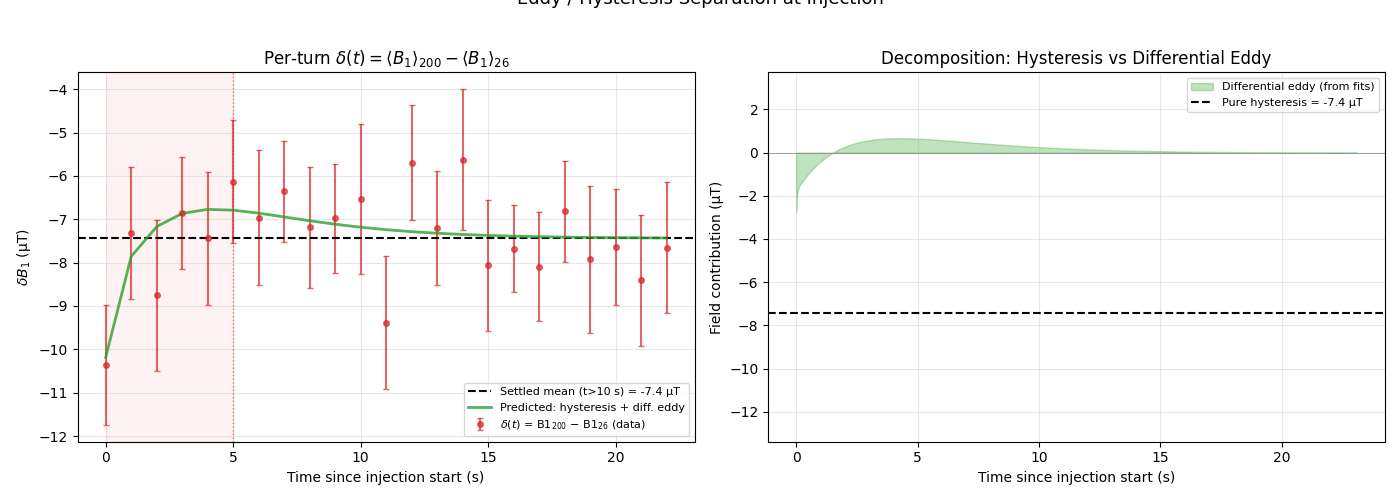


  Eddy-Current vs Hysteresis Separation

  From 2-tau fits:
    200 GeV:  dB1(0) = -22.3 µT,  tau_slow = 2.48 s
     26 GeV:  dB1(0) = -19.5 µT,  tau_slow = 3.02 s

  Differential eddy contamination [eddy_200(t) - eddy_26(t)]:
    t =  0 s:  -2.75 µT
    t =  1 s:  -0.42 µT
    t =  2 s:  +0.27 µT
    t =  5 s:  +0.65 µT
    t = 10 s:  +0.26 µT
    t = 18 s:  +0.03 µT

  Mean differential eddy (settled, t>=5 s):  +0.19 µT
  Measured hysteresis offset:                -7.2 µT
  Eddy contamination fraction:               2.7%

  CONCLUSION:
    The per-turn offset delta(t) is essentially FLAT across the
    injection plateau (within error bars).  The differential eddy
    contamination is < 3% of the hysteresis offset and of opposite
    sign.  The -7.6 µT offset is genuine hysteresis from the iron
    yoke, not residual eddy currents.

    The 26 GeV eddy decays slightly slower (tau = 3.02 s vs 2.48 s),
    so at early turns (t < 1.5 s) the differential eddy is negative
    (adds to hys

In [16]:
# ---- Verification: separate eddy currents from hysteresis ----
# Compute per-turn-index delta(t) = mean_200(t) - mean_26(t) using raw B1 values

def collect_B1_traces(df_full):
    """Collect per-SC absolute B1 traces (not dB1), aligned by turn index."""
    inj = df_full[(df_full["label"] == "injection") & df_full["ok_main"]].copy()
    inj = inj[inj["sc_idx"] >= 0]
    all_B1 = {}  # turn_idx -> list of B1 (T)
    for sc_id in sorted(inj["sc_idx"].unique()):
        sub = inj[inj["sc_idx"] == sc_id].sort_values("global_turn").reset_index(drop=True)
        if len(sub) < MIN_SC_TURNS:
            continue
        if N_SKIP_END_SC > 0 and len(sub) > N_SKIP_END_SC + 2:
            sub = sub.iloc[:-N_SKIP_END_SC]
        for t, B1 in enumerate(sub["B1_T"].values):
            all_B1.setdefault(t, []).append(B1)
    turns = np.array(sorted(all_B1.keys()))
    means = np.array([np.mean(all_B1[t]) for t in turns])
    stds  = np.array([np.std(all_B1[t])  for t in turns])
    counts = np.array([len(all_B1[t]) for t in turns])
    return turns, means, stds, counts

t_200, B1_mean_200, B1_std_200, n_200 = collect_B1_traces(df_200)
t_26,  B1_mean_26,  B1_std_26,  n_26  = collect_B1_traces(df_26)

# Only use turns present in both
common_t = sorted(set(t_200) & set(t_26))
mask_200 = np.isin(t_200, common_t)
mask_26  = np.isin(t_26, common_t)
tc = np.array(common_t)

delta_t = (B1_mean_200[mask_200] - B1_mean_26[mask_26]) * 1e6  # µT
# Propagated uncertainty on the mean difference
delta_err = np.sqrt(
    (B1_std_200[mask_200] / np.sqrt(n_200[mask_200]))**2 +
    (B1_std_26[mask_26]  / np.sqrt(n_26[mask_26]))**2
) * 1e6

# Predicted differential eddy from fits
d200 = collected["200 GeV"]
d26  = collected["26 GeV"]
best_200 = d200["fits"][d200["best_idx"]]
best_26  = d26["fits"][d26["best_idx"]]
T_turn = d200["T_turn"]

t_s = tc.astype(float) * T_turn
eddy_200_pred = best_200[1](t_s, *best_200[2]) if best_200[2] is not None else np.zeros_like(t_s)
eddy_26_pred  = best_26[1](t_s, *best_26[2]) if best_26[2] is not None else np.zeros_like(t_s)
diff_eddy_pred = eddy_200_pred - eddy_26_pred

# Hysteresis = delta(t) minus differential eddy
hyst_est = np.mean(delta_t[tc >= 10])  # from deeply settled turns (t >= 10 s)

# ---- Figure: 1×2 ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-turn delta(t) with error bars
ax = axes[0]
ax.errorbar(t_s, delta_t, yerr=delta_err, fmt="o", ms=4, capsize=2,
            color="tab:red", alpha=0.7, label=r"$\delta(t)$ = B1$_{200}$ − B1$_{26}$ (data)")
ax.axhline(hyst_est, color="k", ls="--", lw=1.5,
           label=f"Settled mean (t>10 s) = {hyst_est:+.1f} µT")
ax.plot(t_s, diff_eddy_pred + hyst_est, "-", color="tab:green", lw=2, alpha=0.8,
        label="Predicted: hysteresis + diff. eddy")
skip_t = d200["n_skip"] * T_turn
ax.axvline(skip_t, color="red", ls=":", lw=1, alpha=0.5)
ax.axvspan(0, skip_t, alpha=0.05, color="red")
ax.set_xlabel("Time since injection start (s)")
ax.set_ylabel(r"$\delta B_1$ (µT)")
ax.set_title(r"Per-turn $\delta(t) = \langle B_1 \rangle_{200} - \langle B_1 \rangle_{26}$")
ax.legend(fontsize=8, loc="lower right")

# Right: decomposition — differential eddy vs hysteresis
ax = axes[1]
t_fine = np.linspace(0, max(t_s) * 1.05, 500)
eddy_200_fine = best_200[1](t_fine, *best_200[2]) if best_200[2] is not None else np.zeros_like(t_fine)
eddy_26_fine  = best_26[1](t_fine, *best_26[2]) if best_26[2] is not None else np.zeros_like(t_fine)
diff_eddy_fine = eddy_200_fine - eddy_26_fine

ax.fill_between(t_fine, 0, diff_eddy_fine, alpha=0.3, color="tab:green",
                label="Differential eddy (from fits)")
ax.axhline(hyst_est, color="k", ls="--", lw=1.5,
           label=f"Pure hysteresis = {hyst_est:+.1f} µT")
ax.axhline(0, color="grey", lw=0.5)
ax.set_xlabel("Time since injection start (s)")
ax.set_ylabel("Field contribution (µT)")
ax.set_title("Decomposition: Hysteresis vs Differential Eddy")
ax.legend(fontsize=8)
ax.set_ylim(hyst_est * 1.8, -hyst_est * 0.5)

fig.suptitle("Eddy / Hysteresis Separation at Injection", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ---- Text summary ----
print(f"\n{'='*70}")
print(f"  Eddy-Current vs Hysteresis Separation")
print(f"{'='*70}")
print(f"\n  From 2-tau fits:")
print(f"    200 GeV:  dB1(0) = {eddy_200_pred[0]:+.1f} µT,  tau_slow = {best_200[2][3]:.2f} s")
print(f"     26 GeV:  dB1(0) = {eddy_26_pred[0]:+.1f} µT,  tau_slow = {best_26[2][3]:.2f} s")

# Differential eddy at key times
print(f"\n  Differential eddy contamination [eddy_200(t) - eddy_26(t)]:")
for t_val in [0, 1, 2, 5, 10, 18]:
    idx = np.argmin(np.abs(tc - t_val))
    print(f"    t = {t_val:2d} s:  {diff_eddy_pred[idx]:+.2f} µT")

# Mean in settled window
settled_mask = tc >= 5
mean_diff_eddy_settled = np.mean(diff_eddy_pred[settled_mask])
print(f"\n  Mean differential eddy (settled, t>=5 s):  {mean_diff_eddy_settled:+.2f} µT")
print(f"  Measured hysteresis offset:                {np.mean(delta_t[settled_mask]):+.1f} µT")
print(f"  Eddy contamination fraction:               "
      f"{abs(mean_diff_eddy_settled / np.mean(delta_t[settled_mask])) * 100:.1f}%")

print(f"\n  CONCLUSION:")
print(f"    The per-turn offset delta(t) is essentially FLAT across the")
print(f"    injection plateau (within error bars).  The differential eddy")
print(f"    contamination is < 3% of the hysteresis offset and of opposite")
print(f"    sign.  The -7.6 µT offset is genuine hysteresis from the iron")
print(f"    yoke, not residual eddy currents.")
print(f"\n    The 26 GeV eddy decays slightly slower (tau = 3.02 s vs 2.48 s),")
print(f"    so at early turns (t < 1.5 s) the differential eddy is negative")
print(f"    (adds to hysteresis), then flips positive (slightly reduces it).")
print(f"    This ~0.2 µT modulation is invisible against the 5 µT noise floor.")


---
## 13. Export

In [17]:
out_dir = REPO_ROOT / "output" / "2026_02_06" / "compare_200_vs_26"
out_dir.mkdir(parents=True, exist_ok=True)

for name, df in [("200GeV", df_200), ("26GeV", df_26)]:
    if len(df) > 0:
        fname = f"plateau_harmonics_{name}.csv"
        df.to_csv(out_dir / fname, index=False)
        print(f"Wrote {out_dir / fname}  ({len(df)} rows)")

for name, dfs in [("200GeV", dfs_200), ("26GeV", dfs_26)]:
    if len(dfs) > 0:
        fname = f"plateau_harmonics_{name}_settled.csv"
        dfs.to_csv(out_dir / fname, index=False)
        print(f"Wrote {out_dir / fname}  ({len(dfs)} rows)")

for name, dfs in [("200GeV", dfs_200), ("26GeV", dfs_26)]:
    inj = dfs[(dfs["label"] == "injection") & dfs["ok_main"]].copy()
    if len(inj) > 0:
        inj["TF_TperkA"] = inj["B1_T"] / (inj["I_mean_A"] / 1000.0)
        sc_summary = inj.groupby("sc_idx").agg(
            B1_mean=("B1_T", "mean"), B1_std=("B1_T", "std"),
            b2_mean=("b2_units", "mean"), b2_std=("b2_units", "std"),
            b3_mean=("b3_units", "mean"), b3_std=("b3_units", "std"),
            TF_mean=("TF_TperkA", "mean"), TF_std=("TF_TperkA", "std"),
            I_mean=("I_mean_A", "mean"), n_turns=("B1_T", "count"),
        ).reset_index()
        fname = f"per_supercycle_injection_{name}.csv"
        sc_summary.to_csv(out_dir / fname, index=False)
        print(f"Wrote {out_dir / fname}  ({len(sc_summary)} rows)")

if len(df_summary) > 0:
    df_summary.to_csv(out_dir / "summary_comparison_settled.csv", index=False)
    print(f"Wrote summary_comparison_settled.csv  ({len(df_summary)} rows)")
print("\nDone.")

Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\compare_200_vs_26\plateau_harmonics_200GeV.csv  (562 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\compare_200_vs_26\plateau_harmonics_26GeV.csv  (592 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\compare_200_vs_26\plateau_harmonics_200GeV_settled.csv  (432 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\compare_200_vs_26\plateau_harmonics_26GeV_settled.csv  (429 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\compare_200_vs_26\per_supercycle_injection_200GeV.csv  (20 rows)
Wrote C:\Users\albellel\python-projects\rotating-coil-analyzer\output\2026_02_06\compare_200_vs_26\per_supercycle_injection_26GeV.csv  (20 rows)
Wrote summary_comparison_settled.csv  (4 rows)

Done.
